In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

read dataset

In [100]:
df=pd.read_csv('/content/House_Rent_Dataset.csv')

over view of dataset

In [101]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


all columns

In [102]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

number of rows

In [103]:
df['Area Locality'].count()

np.int64(4746)

number of null values

In [104]:
df.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


number of duplicate rows

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


statics of data set

In [108]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


convert data type

In [109]:
df['Posted On']=pd.to_datetime(df['Posted On'])

new columns

In [110]:
df['Posted On month']=df['Posted On'].dt.month
df['Posted On year']=df['Posted On'].dt.year

detect outliers

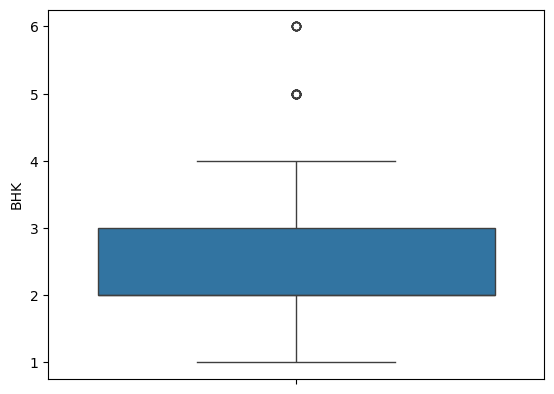

In [111]:
sns.boxplot(df['BHK'])
plt.show()

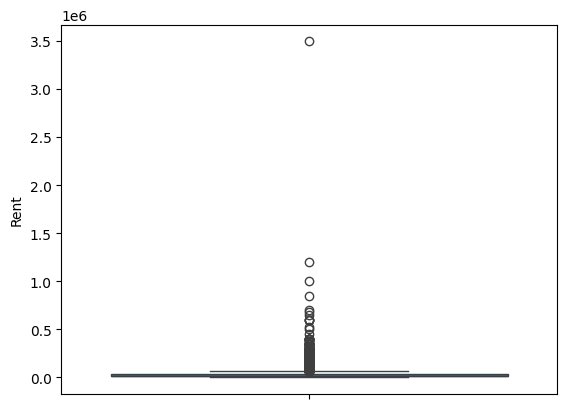

In [112]:
sns.boxplot(df['Rent'])
plt.show()

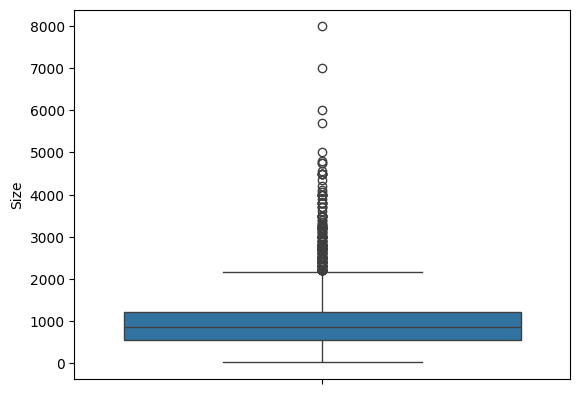

In [113]:
sns.boxplot(df['Size'])
plt.show()

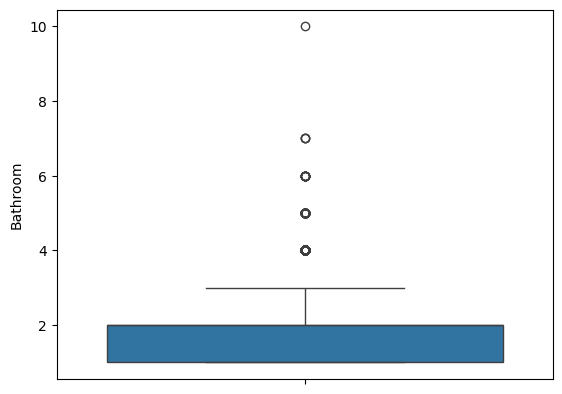

In [114]:
sns.boxplot(df['Bathroom'])
plt.show()

remove outlier

using IQR method

/tmp/ipykernel_8111/2108763696.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[(df['BHK']>=bhk_q1) & (df['BHK']<=bhk_q3)]['BHK'])


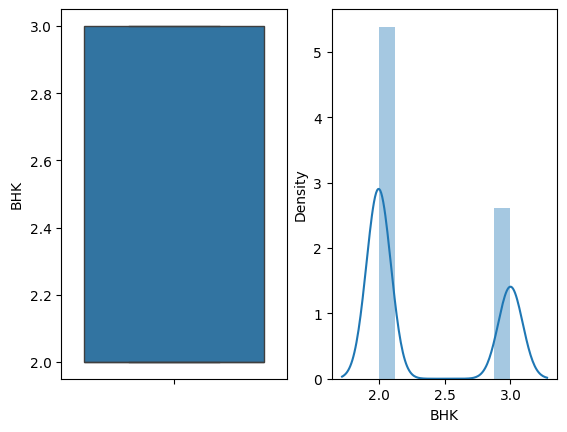

In [115]:
bhk_q1=df['BHK'].quantile(0.25)
bhk_q3=df['BHK'].quantile(0.75)
plt.subplot(1,2,1)
sns.boxplot(df[(df['BHK']>=bhk_q1) & (df['BHK']<=bhk_q3)]['BHK'])
plt.subplot(1,2,2)
sns.distplot(df[(df['BHK']>=bhk_q1) & (df['BHK']<=bhk_q3)]['BHK'])
plt.show()

using Z-Score method

/tmp/ipykernel_8111/862855929.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[(df['z_score_size']>=-2) & (df['z_score_size']<=2)]['Size'])


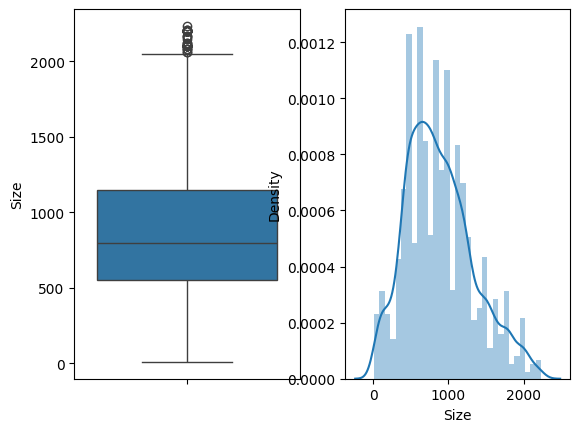

In [116]:
size_mean=df['Size'].mean()
size_std=df['Size'].std()
df['z_score_size']=(df['Size']-size_mean)/size_std
plt.subplot(1,2,1)
sns.boxplot(df[(df['z_score_size']>=-2) & (df['z_score_size']<=2)]['Size'])
plt.subplot(1,2,2)
sns.distplot(df[(df['z_score_size']>=-2) & (df['z_score_size']<=2)]['Size'])
plt.show()

/tmp/ipykernel_8111/4284043362.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[(df['z_score_bathroom']>=-2) & (df['z_score_bathroom']<=2)]['Bathroom'])


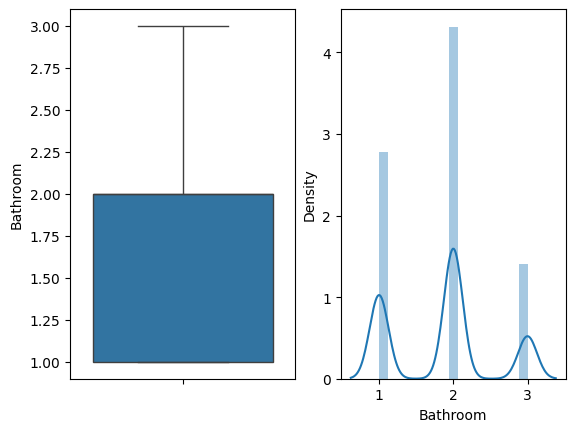

In [117]:
bathroom_mean=df['Bathroom'].mean()
bathroom_std=df['Bathroom'].std()
df['z_score_bathroom']=(df['Bathroom']-bathroom_mean)/bathroom_std
plt.subplot(1,2,1)
sns.boxplot(df[(df['z_score_bathroom']>=-2) & (df['z_score_bathroom']<=2)]['Bathroom'])
plt.subplot(1,2,2)
sns.distplot(df[(df['z_score_bathroom']>=-2) & (df['z_score_bathroom']<=2)]['Bathroom'])
plt.show()

Encoding

In [119]:
from sklearn.preprocessing import OrdinalEncoder
floor_encoding=OrdinalEncoder()
df['Floor_encoding']=floor_encoding.fit_transform(df[['Floor']])
df.head(10)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Posted On month,Posted On year,z_score_size,z_score_bathroom,Floor_encoding
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,5,2022,0.208938,0.038590,455.0
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5,2022,-0.264097,-1.091952,14.0
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5,2022,0.051260,-1.091952,14.0
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,7,2022,-0.264097,-1.091952,10.0
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,5,2022,-0.185257,-1.091952,10.0
5,2022-04-29,2,7000,600,Ground out of 1,Super Area,Thakurpukur,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,4,2022,-0.579453,0.038590,447.0
6,2022-06-21,2,10000,700,Ground out of 4,Super Area,Malancha,Kolkata,Unfurnished,Bachelors,2,Contact Agent,6,2022,-0.421775,0.038590,458.0
7,2022-06-21,1,5000,250,1 out of 2,Super Area,Malancha,Kolkata,Unfurnished,Bachelors,1,Contact Agent,6,2022,-1.131328,-1.091952,10.0
8,2022-06-07,2,26000,800,1 out of 2,Carpet Area,"Palm Avenue Kolkata, Ballygunge",Kolkata,Unfurnished,Bachelors,2,Contact Agent,6,2022,-0.264097,0.038590,10.0
9,2022-06-20,2,10000,1000,1 out of 3,Carpet Area,Natunhat,Kolkata,Semi-Furnished,Bachelors/Family,2,Contact Owner,6,2022,0.051260,0.038590,14.0


In [120]:
from sklearn.preprocessing import LabelEncoder
area_type_encoding=LabelEncoder()
df['Area_type_encoding']=area_type_encoding.fit_transform(df['Area Type'])
df['Area_type_encoding'].head()

,Area_type_encoding
0,2
1,2
2,2
3,2
4,1


In [121]:
from sklearn.preprocessing import LabelEncoder
city_encoding=LabelEncoder()
df['City_encoding']=city_encoding.fit_transform(df[['City']])
df['City_encoding'].head()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,City_encoding
0,4
1,4
2,4
3,4
4,4


In [122]:
from sklearn.preprocessing import LabelEncoder
area_locality_encoding=LabelEncoder()
df['Area_locality_encoding']=area_locality_encoding.fit_transform(df[['Area Locality']])
df['Area_locality_encoding'].head()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Area_locality_encoding
0,221
1,1527
2,1760
3,526
4,1890


In [123]:
from sklearn.preprocessing import LabelEncoder
furnishing_status_encoding=LabelEncoder()
df['Furnishing_status_encoding']=furnishing_status_encoding.fit_transform(df[['Furnishing Status']])
df['Furnishing_status_encoding'].head()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Furnishing_status_encoding
0,2
1,1
2,1
3,2
4,2


In [124]:
from sklearn.preprocessing import LabelEncoder
tenant_preferred_encoding=LabelEncoder()
df['Tenant_preferred_encoding']=tenant_preferred_encoding.fit_transform(df[['Tenant Preferred']])
df['Tenant_preferred_encoding'].head()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Tenant_preferred_encoding
0,1
1,1
2,1
3,1
4,0


train-test split

In [127]:
from sklearn.model_selection import train_test_split
x=df[((df['BHK']>=bhk_q1) & (df['BHK']<=bhk_q3)) & ((df['z_score_size']>=-2) & (df['z_score_size']<=2)) & ((df['z_score_bathroom']>=-2) & (df['z_score_bathroom']<=2))][['Posted On month','Posted On year','BHK','Size','Bathroom','Floor_encoding','Area_type_encoding','City_encoding','Area_locality_encoding','Furnishing_status_encoding','Tenant_preferred_encoding']]
y=df[((df['BHK']>=bhk_q1) & (df['BHK']<=bhk_q3)) & ((df['z_score_size']>=-2) & (df['z_score_size']<=2)) & ((df['z_score_bathroom']>=-2) & (df['z_score_bathroom']<=2))][['Rent']]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

learn model

In [128]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

house rent pretiction

In [132]:
# 'Posted On month','Posted On year','BHK','Size','Bathroom','Floor_encoding','Area_type_encoding','City_encoding','Area_locality_encoding','Furnishing_status_encoding','Tenant_preferred_encoding'
y_pred=model.predict(x_test)

R^2 score

In [134]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R2 Score:", score)

R2 Score: 0.43547693709591895
